In [1]:
import argparse
import cmath
import json
import os
import sys
import time

import basix
import dolfinx
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import scifem
import ufl

from dolfinx import fem, mesh

from dolfinx.cpp.mesh import cell_num_entities

from dolfinx.fem.petsc import assemble_matrix_block, assemble_vector_block, NonlinearProblem
from dolfinx.fem import petsc
from dolfinx.geometry import bb_tree, compute_collisions_points, compute_colliding_cells
from dolfinx.io import gmshio, VTXWriter
from dolfinx.nls import petsc as petsc_nls
from mpi4py import MPI
from petsc4py import PETSc
from ufl import avg, div, dot, grad, inner, jump

import commons, mesh_utils, solver_params, solvers, utils

In [2]:
params = {
    # 'text.usetex': True,
    'figure.figsize': (5, 4.5),
    'font.size' : 12,
    'font.family': 'monospace',
    'axes.labelsize': 12,
    'lines.linewidth': 1.0,
    'legend.fontsize': 12,
    'xtick.direction': "in",
    'xtick.top': True,
    'xtick.minor.visible': True,
    'ytick.direction': "in",
    'ytick.minor.visible': True,
    'ytick.right': True,
    'savefig.format': 'eps',
}
plt.rcParams.update(params)

In [3]:
figures_dir = "shunt-currents"
if not os.path.exists(figures_dir):
    os.mkdir(figures_dir)

## Linearization of port current $i_p$ when $\alpha_a = \alpha_c = \alpha = 0.5$


### $
\begin{equation}
i_p = \Bigl({\frac{2 a i_0  \kappa  R  T}{\alpha^2 F}}\Bigr)^{1/2}\alpha^{1/2}\Bigl(-2 + e^{\frac{\alpha F}{R T}\phi} + e^{\frac{-\alpha F}{R T}\phi}\Bigr)^{1/2}
\end{equation}
$

### $
\begin{equation}
i_0^{'} = \Bigl({\frac{2 a i_0  \kappa  R  T}{\alpha F}}\Bigr)^{1/2}
\end{equation}
$

### $
\begin{equation}
\frac{\mathrm{d}i_p}{\mathrm{d}\phi} = i_0^{'}\frac{\alpha F}{R  T}\frac{\sinh{(\frac{\alpha F}{R T}\phi)}}{\Bigl(-2 + e^{\frac{\alpha F}{R T}\phi} + e^{\frac{-\alpha F}{R T}\phi}\Bigr)^{1/2}} = \frac{ {i_0^{'}}^2 }{i_p} \frac{\alpha F}{R  T}\sinh{(\frac{\alpha F}{R T}\phi)}
\end{equation}
$

### $
m \equiv \frac{\mathrm{d}i_p}{\mathrm{d}\phi}|_{\phi=V_0}
$

### $
i_p \approx i_p(V_0) + m (\phi - V_0)
$
### $
\phi = \frac{i_p}{m} - \frac{i_p(V_0)}{m} + V_0
$

### $
\begin{equation}
\lambda^2 \equiv \frac{H_p}{\kappa A_m}\frac{m}{mR_p + 1}
\end{equation}
$

## $
\begin{equation}
\frac{\mathrm{d}^2\phi}{\mathrm{d}y^2} + \lambda^2\phi = \lambda^2 \Bigl( \frac{V_{\mathrm{cell}}}{\delta_p}y - \frac{i_p(V_0)}{m} + V_0\Bigr)
\end{equation}
$

In [4]:
faraday_const = 96485
R = 8.3145
T = 298

a = 100
i0 = 10
kappa = 4

alpha = 0.5
V0 = 1e-8  # linearization potential
L_p = 0.02
H_p = 0.03
A_m = 0.006
V_cell = 1.0
d_p = 0.01
N_s = 100
L = N_s * d_p/2
R_p = L_p / kappa

w = 99

dtype = PETSc.ScalarType

In [5]:
i0_prime = ((2 * a * i0 / alpha) * (kappa * R * T / faraday_const)) ** 0.5

In [6]:
comm = MPI.COMM_WORLD
domain = mesh.create_interval(comm, 20000, [0, L])
tdim = domain.topology.dim
fdim = tdim - 1
ft_imap = domain.topology.index_map(fdim)
num_facets = ft_imap.size_local + ft_imap.num_ghosts
indices = np.arange(0, num_facets)
values = np.zeros(indices.shape, dtype=np.intc)
left_marker = 1
right_marker = 2

values[0] = left_marker
values[-1] = right_marker
ft = mesh.meshtags(domain, fdim, indices, values)

x = ufl.SpatialCoordinate(domain)
n = ufl.FacetNormal(domain)

In [7]:
def left_boundary(x):
    return np.isclose(x[0], 0)

def right_boundary(x):
    return np.isclose(x[0], L)

In [8]:
V = fem.functionspace(domain, ("CG", 2))

In [9]:
u, v = fem.Function(V), ufl.TestFunction(V)
u0 = fem.Function(V)
u0.interpolate(lambda x: x[0] - x[0] + 1e-8)

In [10]:
dx = ufl.Measure('dx', domain=domain)
ds = ufl.Measure('ds', domain=domain, subdomain_data=ft)

In [11]:
u_left = fem.Function(V)
u_left.x.array[:] = 0
domain.topology.create_connectivity(fdim, tdim)
left_bc = fem.dirichletbc(
    u_left, fem.locate_dofs_topological(V, fdim, ft.find(left_marker))
)

bcs = [left_bc]

In [12]:
def func_0(V=V0):
    xi = alpha * faraday_const / (R * T)
    coef = np.sqrt(2 * a * i0 / (alpha ** 2) * (kappa * R * T/faraday_const))
    return coef * (alpha * np.exp(xi * V) + alpha * np.exp(-xi*V) - 1) ** 0.5


def slope_0(V=V0):
    xi = alpha * faraday_const / (R * T)
    coef = np.sqrt(2 * a * i0 / (alpha ** 2) * (kappa * R * T/faraday_const))
    return coef * 0.5 * (-alpha * xi * np.exp(xi * V) + alpha * xi * np.exp(-xi*V)) / (-1 + alpha * np.exp(xi*V) + alpha * np.exp(-xi*V)) ** 0.5

In [13]:
def i_port(V=V0):
    return i0_prime * ufl.sqrt(-2 + ufl.exp(alpha * faraday_const * V / R / T) + ufl.exp(-alpha * faraday_const * V / R / T))

def m(V=V0):
    return i0_prime ** 2 * (alpha * faraday_const / R / T) * ufl.sinh(alpha * faraday_const / R / T) / i_port(V=V)

def lambda_squared(V=V0):
    return H_p / (kappa * A_m) * m(V=V) / (m(V=V) * R_p - 1)

def f(y, V=V0):
    return lambda_squared(V=V) * (V_cell / d_p * y - i_port(V=V)/m(V=V) - V)

def I_m(u):
    return -kappa * A_m * ufl.grad(u)

def I_ds(u):
    return 1 / L * fem.assemble_scalar(fem.form(I_m(u) * dx))

In [14]:
lambda_sq = H_p / (kappa * A_m * R_p * (1 - 1/(slope_0() * R_p)))
source = lambda_sq * (V_cell / d_p * x[0] - func_0()/slope_0())
print(lambda_sq ** 0.5)
lambda_sq = H_p / A_m * 1 / (L_p + 1/w)
source = -H_p/A_m * (V_cell/d_p * x[0]) / (L_p + 1/w)
lmbda = lambda_sq ** 0.5
print(lambda_sq ** 0.5)

12.876117656299197
12.88826530415694


In [15]:
tol = 1e-8

max_its = 10
# depends on N_s, λ ** 2, L_p, d_p, H_p, A_m, w, V_cell, κ
def run_model(tol=1e-8, max_its=10):
    it = 0
    error = tol + 1
    x_fun = fem.Function(u.function_space)
    x_fun.interpolate(lambda x: x[0])
    
    while error > tol and it < max_its:
        F0 = -inner(kappa * grad(u), grad(v)) * dx  - (lambda_squared(V=u0) * u - f(x[0], V=u0)) * v * dx
        F = [fem.form(F0)]
        j00 = fem.form(ufl.derivative(F0, u))
        J = [[j00]]
        opts = {
                    'ksp_type': 'fgmres',
                    'pc_type': 'hypre',
                    }
        
        solver = scifem.NewtonSolver(F, J, [u], bcs=bcs, petsc_options=opts)
        
        t0 = time.time()
        solver.solve()
        t1 = time.time()
        error = np.sqrt(fem.assemble_scalar(fem.form(((x[0] - 2 * u/N_s - u0)) ** 2 * dx)))
        u0.x.array[:] = x_fun.x.array - 2 * u.x.array / N_s
        PETSc.Sys.Print(f"Iteration: {it}, Error: {error:.2e}, Solve time: {t1 - t0:.3f}s")
        it += 1
    return error <= tol, it

In [16]:
run_model()

Iteration: 0, Error: 1.48e-01, Solve time: 0.278s
Iteration: 1, Error: 2.55e-03, Solve time: 0.216s
Iteration: 2, Error: 4.40e-05, Solve time: 0.146s
Iteration: 3, Error: 7.59e-07, Solve time: 0.159s
Iteration: 4, Error: 1.31e-08, Solve time: 0.182s
Iteration: 5, Error: 2.27e-10, Solve time: 0.168s


(True, 6)

In [17]:
def phi_linear(y):
    return (-V_cell/d_p/lambda_sq ** 0.5)/(2 * np.cosh(lambda_sq ** 0.5 * L)) * (2 * np.sinh(lambda_sq ** 0.5 * y)) + V_cell * y / d_p

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


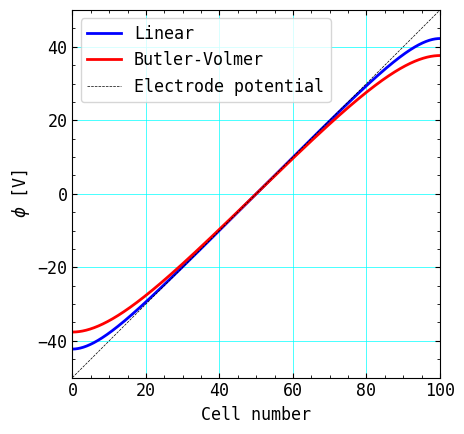

In [18]:
bb_trees = bb_tree(domain, domain.topology.dim)
n_points = 10000
tol = 1e-8  # Avoid hitting the outside of the domain
x = np.linspace(tol, L - tol, n_points)
points = np.zeros((3, n_points))
points[0] = x
u_values = []
cells = []
points_on_proc = []
cell_candidates = compute_collisions_points(bb_trees, points.T)
colliding_cells = compute_colliding_cells(domain, cell_candidates, points.T)
for i, point in enumerate(points.T):
    if len(colliding_cells.links(i)) > 0:
        points_on_proc.append(point)
        cells.append(colliding_cells.links(i)[0])
points_on_proc = np.array(points_on_proc, dtype=np.float64)
u_values = u.eval(points_on_proc, cells)
fig, ax = plt.subplots()
y = np.hstack((-points_on_proc[::-1, 0], points_on_proc[:, 0]))
x_lin = 0.5 * N_s + y/d_p
u_lin = phi_linear(y)
x_lin.reshape(-1, 1)
u_lin.reshape(-1, 1)
u_bv = np.vstack((-u_values[::-1], u_values[:]))
ax.plot(x_lin, u_lin, "b", label='Linear', linewidth=2)
ax.plot(x_lin, u_bv, "r", label='Butler-Volmer', linewidth=2)
ax.plot([0, 100], [-50, 50], 'k', linewidth=0.5, linestyle='--', label='Electrode potential')
ax.grid(color='cyan', linewidth=0.5)
ax.set_ylabel(r'$\phi$ [V]')
ax.set_xlabel(r'Cell number')
ax.set_xlim([0, N_s])
ax.set_ylim([-50, 50])
ax.legend()
ax.set_box_aspect(1);
ax.minorticks_on();
plt.tight_layout()
plt.savefig(os.path.join(figures_dir, "potential.eps"), format="eps")
plt.show()

In [19]:
def i_p(y, phi):
    return (V_cell  * y /d_p - i_port()/m() - phi) / (R_p * (1 - 1/(m() * R_p)))

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


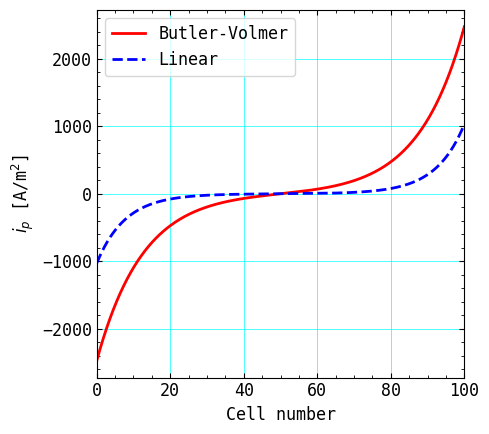

In [20]:
y = np.hstack((-points_on_proc[::-1, 0], points_on_proc[:, 0]))
fig, ax = plt.subplots()
i_p_bv = i_p(y, u_bv[:, 0])
i_p_lin = V_cell * kappa / (L_p + 1/w) / (lmbda * d_p) * (np.sinh(lmbda * y) / np.cosh(lmbda * L))
ax.plot(x_lin, i_p_bv, "r", linewidth=2, label='Butler-Volmer')
ax.plot(x_lin, i_p_lin, "b--", linewidth=2, label='Linear')
ax.set_xlabel(r'Cell number')
ax.set_ylabel(r'$i_p$ [A/m$^2$]')
ax.grid(color='cyan', linewidth=0.5)
ax.set_xlim([0, N_s])
ax.legend()
ax.set_box_aspect(1);
ax.minorticks_on();
plt.tight_layout()
plt.savefig(os.path.join(figures_dir, "port-current.eps"), format="eps")
plt.show()

In [21]:
W = fem.functionspace(domain, ("CG", 2, (1,)))
I_m = fem.Function(W)
I_m_expr = fem.Expression(-kappa * A_m * grad(u), W.element.interpolation_points)
I_m.interpolate(I_m_expr)

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


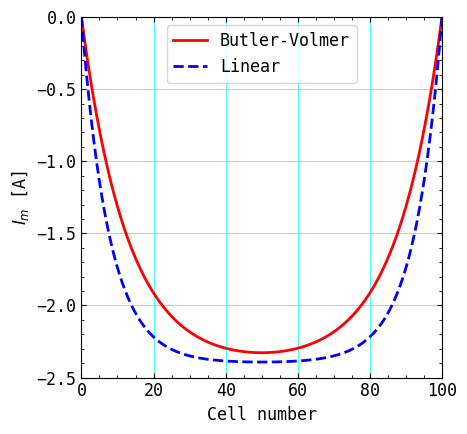

In [22]:
bb_trees = bb_tree(domain, domain.topology.dim)
n_points = 10000
tol = 1e-8  # Avoid hitting the outside of the domain
x = np.linspace(tol, L - tol, n_points)
points = np.zeros((3, n_points))
points[0] = x
I_m_values = []
cells = []
points_on_proc = []
cell_candidates = compute_collisions_points(bb_trees, points.T)
colliding_cells = compute_colliding_cells(domain, cell_candidates, points.T)
for i, point in enumerate(points.T):
    if len(colliding_cells.links(i)) > 0:
        points_on_proc.append(point)
        cells.append(colliding_cells.links(i)[0])
points_on_proc = np.array(points_on_proc, dtype=np.float64)
I_m_values = I_m.eval(points_on_proc, cells)
I_m_bv = np.hstack((I_m_values[::-1, 0], I_m_values[:, 0]))
I_m_lin = V_cell * kappa / (L_p + 1/w) * H_p / (lmbda ** 2 * d_p) * (np.cosh(lmbda * y) / np.cosh(lmbda * L) - 1)

fig, ax = plt.subplots()
ax.plot(x_lin, I_m_bv, "r", linewidth=2, label='Butler-Volmer')
ax.plot(x_lin, I_m_lin, "b--", linewidth=2, label='Linear')
ax.set_ylabel(r'$I_m$ [A]')
ax.set_xlabel(r'Cell number')
ax.set_xlim([0, N_s])
ax.set_ylim([-2.5, 0])
ax.set_box_aspect(1);
ax.legend()
ax.grid(color='cyan', linewidth=0.5)
ax.minorticks_on();
plt.tight_layout()
plt.savefig(os.path.join(figures_dir, "manifold-current.eps"), format="eps")
plt.show()

In [23]:
# def read_json(input_path):
    # with open(input_path, "r") as fp:
    #     results_row = json.load(fp)
    #     results.append(results_row)

In [49]:
results_dir = "shunt-current/L_p"
results = []
L_ports = [0.005, 0.01, 0.015, 0.02, 0.025, 0.03, 0.035, 0.04, 0.045, 0.05]
for L_p in L_ports:
    with open(os.path.join(results_dir, f"{L_p:.3f}.json"), "r") as fp:
        results_row = json.load(fp)
        results_row['L_p'] = L_p
        results.append(results_row)
df = pd.DataFrame(results)

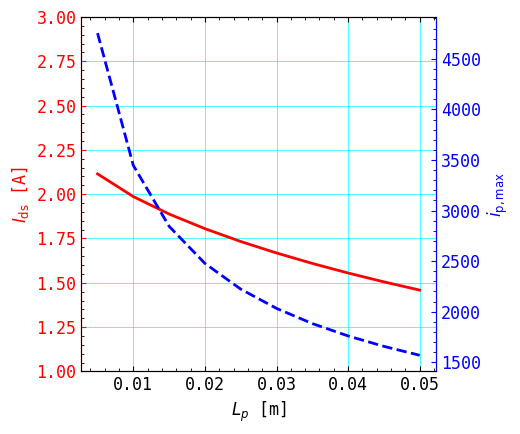

In [50]:
fig, ax = plt.subplots()
ax.plot(df['L_p'], df['I_ds [A]'], "r", linewidth=2, label=r'$I_{\mathrm{ds}}$')
ax.set_ylabel(r'$I_{\mathrm{ds}}$ [A]')
ax.set_xlabel(r'$L_p$ [m]')
ax.set_ylim([1, 3])

ax2 = ax.twinx()
ax2.plot(df['L_p'], df['i_p_max [A/m2]'], "b--", linewidth=2)
ax.set_box_aspect(1);
ax2.set_ylabel(r'$i_{\mathrm{p},\mathrm{max}}$')
# ax.legend()
# ax2.legend()
# ax.set_frame_on(True)
# ax.patch.set_visible(True)
ax.yaxis.label.set_color("red")
ax.spines["left"].set_color("red")

ax2.yaxis.label.set_color("blue")
ax2.spines["right"].set_color("blue")
ax.tick_params(axis='y', colors='red')
ax2.tick_params(axis='y', colors='blue')

ax.grid(color='cyan', linewidth=0.5)
ax.minorticks_on();
plt.tight_layout()
plt.savefig(os.path.join(figures_dir, "L_p-v-I_ds.eps"), format="eps")
plt.show()

In [36]:
results_dir = "shunt-current/N_s"
results = []
N_stack = [20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70, 75, 80, 85, 90, 95, 100]
for N_s in N_stack:
    with open(os.path.join(results_dir, f"{N_s}.json"), "r") as fp:
        results_row = json.load(fp)
        results_row['N_s'] = N_s
        results.append(results_row)
df = pd.DataFrame(results)

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


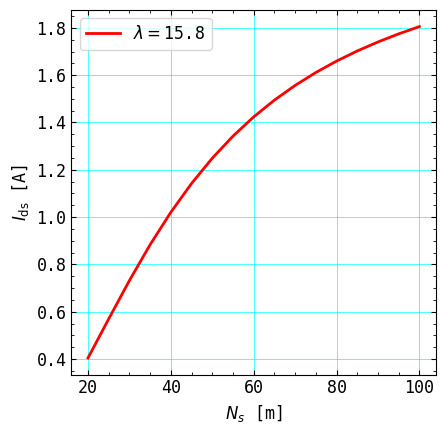

In [38]:
lmda = df['lmda'][0]
fig, ax = plt.subplots()
ax.plot(df['N_s'], df['I_ds [A]'], "r", linewidth=2, label=fr'$\lambda = ${lmda:.1f}')
ax.set_ylabel(r'$I_{\mathrm{ds}}$ [A]')
ax.set_xlabel(r'$N_s$ [m]')
ax.set_box_aspect(1);
ax.grid(color='cyan', linewidth=0.5)
ax.minorticks_on();
ax.legend();
plt.tight_layout()
plt.savefig(os.path.join(figures_dir, "N_s-v-I_ds.eps"), format="eps")
plt.show()

In [43]:
results_dir = "shunt-current/w"
results = []
w_vals = [0.01, 0.1, 1.0, 10.0, 20.0, 50.0, 100.0, 200.0, 500.0, 1000.0, 2000.0, 5000.0, 10000.0]
for w in w_vals:
    with open(os.path.join(results_dir, f"{w}.json"), "r") as fp:
        results_row = json.load(fp)
        results_row['w'] = w
        results.append(results_row)
df = pd.DataFrame(results)

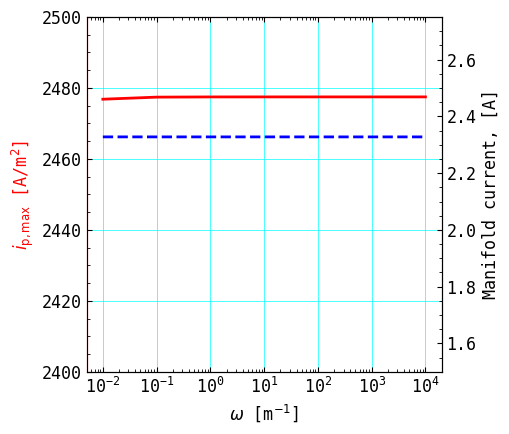

In [47]:
fig, ax = plt.subplots()
ax.semilogx(df['w'], df['i_p_max [A/m2]'], "r", linewidth=2, label=r'$I_{\mathrm{ds}}$')
# ax.semilogx(df['w'], -df['I_ds [A]'], "b", linewidth=2, label=r'$i_{\mathrm{p,max}}$')
ax.set_ylabel(r'$i_{\mathrm{p, max}}$ [A/m$^2$]')
ax.set_xlabel(r'$\omega$ [m$^{-1}$]')

ax2 = ax.twinx()
ax2.semilogx(df['w'], df['I_m,max [A]'], "b--", linewidth=2)
ax.set_box_aspect(1);
ax2.set_ylabel('Manifold current, [A]')
ax2.set_ylim([1.5, 2.75])
# ax.legend()
# ax2.legend()
# ax.set_frame_on(True)
# ax.patch.set_visible(True)
ax.yaxis.label.set_color("red")
ax.spines["left"].set_color("red")

# ax2.yaxis.label.set_color("blue")
# ax2.spines["right"].set_color("blue")
# ax.tick_params(axis='y', colors='red')
# ax2.tick_params(axis='y', colors='blue')
ax.set_ylim([2400, 2500])
ax.grid(color='cyan', linewidth=0.5)
ax.minorticks_on();

ax.set_box_aspect(1);
ax.grid(color='cyan', linewidth=0.5)
ax.minorticks_on();
plt.tight_layout()
plt.savefig(os.path.join(figures_dir, "w-v-i_p_max.eps"), format="eps")
plt.show()